In [3]:
import pandas as pd

#read the dataset with name "Fake_Real_Data.csv" and store it in a variable df
df_fake = pd.read_csv("Fake.csv")

#print the shape of dataframe
print(df_fake.shape)

#print top 5 rows
df_fake.head(5)

(23481, 4)


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [4]:
#read the dataset with name "Fake_Real_Data.csv" and store it in a variable df
df_true = pd.read_csv("True.csv")

#print the shape of dataframe
print(df_true.shape)

#print top 5 rows
df_true.head(5)

(21417, 4)


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [5]:
df_true['label'] = 0
df_true.sample(5)

,title,text,subject,date,label
6876,"Taiwan's Tsai: no major policy shifts, despite...",WASHINGTON (Reuters) - Taiwan President Tsai I...,politicsNews,"December 6, 2016",0
18630,Iraqi PM presses case for Baghdad to receive K...,BAGHDAD (Reuters) - Iraqi Prime Minister Haide...,worldnews,"September 30, 2017",0
17315,From Haider to Strache - the FPO's march to re...,VIENNA (Reuters) - Founded by former Nazis six...,worldnews,"October 16, 2017",0
4071,Ryan says 'getting really close' to U.S. gover...,WASHINGTON (Reuters) - House of Representative...,politicsNews,"April 26, 2017",0
19153,U.N. medics see evidence of rape in Myanmar ar...,"COX S BAZAR, Bangladesh (Reuters) - Doctors tr...",worldnews,"September 24, 2017",0


In [6]:
df_fake['label'] = 1
df_fake.sample(5)

,title,text,subject,date,label
14450,"COUGHING, BARKING, SCREECHING: Hillary Has Dem...",Democrats are in panic mode since Hillary Clin...,politics,"Feb 19, 2016",1
20092,NOT KIDDING: Obama’s Weak Immigrant Vetting Pr...,This new information just adds more validity T...,left-news,"Aug 20, 2016",1
19128,OOPS! Media Forgot Ted Kennedy Asked Russia To...,In 1991 a reporter for the London Times found ...,left-news,"Feb 16, 2017",1
17454,TROLL CONGRESSWOMAN WANTS YOU TO SELL YOUR GUN...,It s not for her to decide! We have the Second...,Government News,"Apr 6, 2015",1
20989,The “ISLAMIC RAPE OF EUROPE”…One Nation Is Fig...,"As an American of Polish descent, I am proud t...",left-news,"Feb 17, 2016",1


In [7]:
df = pd.concat([df_true, df_fake], ignore_index=True)
print(df.shape)
df.sample(5)

(44898, 5)


,title,text,subject,date,label
9192,Exclusive: Obama approves broader role for U.S...,WASHINGTON (Reuters) - President Barack Obama ...,politicsNews,"June 10, 2016",0
5394,Trump dismisses Russia controversy as 'scam' b...,WASHINGTON (Reuters) - President Donald Trump ...,politicsNews,"February 16, 2017",0
22071,It Took A Democratic Governor To Finally Call...,Maybe you ve finally heard by now that a mosqu...,News,"August 6, 2017",1
42531,UFC Fighter And Former U.S. Special Forces Sni...,This hero s response to the threat of Islamic ...,left-news,"Jan 16, 2016",1
18039,Likely successor to Cuba's Castro rejects U.S....,HAVANA (Reuters) - The man forecast to replace...,worldnews,"October 8, 2017",0


In [8]:
df['Text'] = df['title'] + " " + df['text']
df.sample(5)

,title,text,subject,date,label,Text
15574,Petition filed in Kenya court challenging Keny...,NAIROBI (Reuters) - A former lawmaker filed a ...,worldnews,"November 6, 2017",0,Petition filed in Kenya court challenging Keny...
15915,Ireland says would insist on Northern Ireland ...,DUBLIN (Reuters) - The Irish government would ...,worldnews,"November 1, 2017",0,Ireland says would insist on Northern Ireland ...
3822,Trump will not visit FBI headquarters: MSNBC,WASHINGTON (Reuters) - President Donald Trump ...,politicsNews,"May 11, 2017",0,Trump will not visit FBI headquarters: MSNBC W...
38062,BREAKING: OBAMA SUCCESSFULLY WHITEWASHES AMERI...,The irony in Obama s radical Treasury Secretar...,Government News,"Apr 20, 2016",1,BREAKING: OBAMA SUCCESSFULLY WHITEWASHES AMERI...
41319,LIBERAL DUMMY GARY JOHNSON Can’t Name One Fore...,Maybe comedy is a better career choice for Gar...,left-news,"Sep 29, 2016",1,LIBERAL DUMMY GARY JOHNSON Can’t Name One Fore...


In [11]:
import spacy
nlp = spacy.load("en_core_web_lg")

In [10]:
!python -m spacy download en_core_web_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 1.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [12]:
df['vector'] = df['Text'].apply(lambda text: nlp(text).vector)

In [13]:
df.sample(5)

,title,text,subject,date,label,Text,vector
40618,FIRE THIS WOMAN! RANTING NYU PROFESSOR GOES AP...,Please RT until we identify this disgusting N...,left-news,"Feb 3, 2017",1,FIRE THIS WOMAN! RANTING NYU PROFESSOR GOES AP...,"[-0.1460194, 0.081342585, 0.018536597, 0.04457..."
16843,Iraqi forces complete Kirkuk province takeover...,"BAGHDAD/ERBIL, Iraq (Reuters) - Iraqi forces o...",worldnews,"October 20, 2017",0,Iraqi forces complete Kirkuk province takeover...,"[-0.045103163, 0.06799043, 0.0264952, 0.040329..."
10746,Wealthy donors drawn to Rubio White House bid ...,NEW YORK (Reuters) - Within minutes of Jeb Bus...,politicsNews,"February 21, 2016",0,Wealthy donors drawn to Rubio White House bid ...,"[-0.04246643, 0.16362016, -0.018406538, -0.029..."
4775,House conservatives remain opposed to healthca...,WASHINGTON (Reuters) - The head of the U.S. Ho...,politicsNews,"March 22, 2017",0,House conservatives remain opposed to healthca...,"[-0.010594445, 0.10912018, -0.03278839, 0.0393..."
39471,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,left-news,"Aug 27, 2017",1,About Time! Christian Group Sues Amazon and SP...,"[-0.079496495, 0.12899108, -0.08535684, 0.0070..."


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.vector.values,
    df.label,
    test_size=0.2,
    random_state=2022
)

In [15]:
import numpy as np

X_train_2d = np.stack(X_train)
X_test_2d = np.stack(X_test)

In [16]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler


scaler = MinMaxScaler()
scaled_train_embed = scaler.fit_transform(X_train_2d)
scaled_test_embed = scaler.transform(X_test_2d)


clf = MultinomialNB()
clf.fit(scaled_train_embed, y_train)

MultinomialNB()

In [19]:
from sklearn.metrics import classification_report

y_pred = clf.predict(scaled_test_embed)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.86      0.87      4206
           1       0.88      0.89      0.89      4774

    accuracy                           0.88      8980
   macro avg       0.88      0.88      0.88      8980
weighted avg       0.88      0.88      0.88      8980



In [20]:
from  sklearn.neighbors import KNeighborsClassifier

#1. creating a KNN model object
clf = KNeighborsClassifier(n_neighbors = 5, metric = 'euclidean')

#2. fit with all_train_embeddings and y_train
clf.fit(X_train_2d, y_train)

#3. get the predictions for all_test_embeddings and store it in y_pred
y_pred = clf.predict(X_test_2d)

#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      4206
           1       0.98      0.94      0.96      4774

    accuracy                           0.95      8980
   macro avg       0.95      0.96      0.95      8980
weighted avg       0.96      0.95      0.95      8980



Text(95.72222222222221, 0.5, 'Truth')

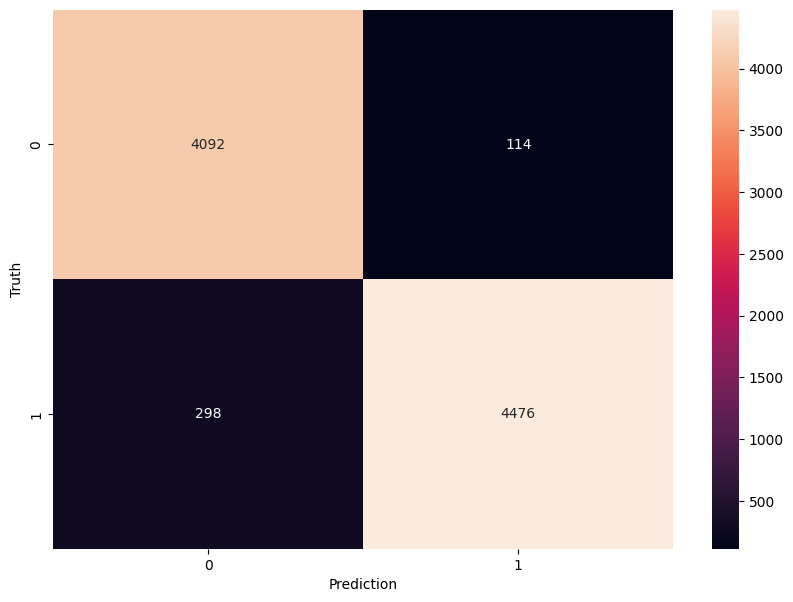

In [21]:
#finally print the confusion matrix for the best model
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

from matplotlib import pyplot as plt
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Truth')